<div class="alert">Fit a single SSO with ssHG1G2</div>

In [3]:
import os
import time
import sys
sys.path.append("..")


import numpy as np

import ssptools
from astropy.coordinates import SkyCoord
import rocks

from fink_utils.sso.spins import estimate_sso_params, func_sshg1g2 #, func_hg1g2, cos_aspect_angle
from fink_utils.sso.periods import estimate_synodic_period 
from fink_utils.sso.utils import (compute_light_travel_correction, estimate_axes_ratio)

import matplotlib.pyplot as plt


# import seaborn as sns
# sns.set_context("poster")

In [4]:
fink_colors = ["#15284F", "#F5622E"]

# Functions to add to fink-utils

In [6]:
def angle_between_vectors(v1, v2):
    """
    Compute the angle between two 3D vectors.

    Parameters
    ----------
    v1 : list or np.ndarray
        The first 3D vector.
    v2 : list or np.ndarray
        The second 3D vector.

    Returns
    -------
    float
        The angle between the two vectors in radians.
    """
    v1 = np.array(v1)
    v2 = np.array(v2)

    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    cos_theta = dot_product / (norm_v1 * norm_v2)
    angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clip to handle numerical issues

    return angle


# Example usage
# v1 = [1.0, 0, 0]
# v2 = [-1.0, -1.0, 1]
# angle = angle_between_vectors(v1, v2)
# print(f"The angle between the vectors is {np.degrees(angle):.2f} degrees")

def synodic_to_sidereal(synodic_period, X):
    """
    Convert synodic rotation period to sidereal rotation period.

    TBD

    Parameters
    ----------
    synodic_period : float
        Synodic rotation period in days.

    Returns
    -------
    sidereal_period : float
        Sidereal rotation period in days.
    """
    sidereal_period = synodic_period
    return sidereal_period

# Target definition

In [14]:
ssnamenr = 5209
ssnamenr = 136108 # KBO = fixed = Haumea
# ssnamenr = 186153 # High frequency observation
# ssnamenr = 223 # Example article 
# ssnamenr = 9799 # JTO lotta obs

# ssnamenr = 17365 # 1978VF11 Thymbareus

ssnamenr = 1139

ssocard = rocks.Rock(ssnamenr)
name, num = ssocard.name, ssocard.number
name, num

('Atami', 1139)

## Period estimation

In [15]:
flavor = "SHG1G2"

period_range = (1 / 24, 7)  # 1hour to 7 days

t0 = time.time()
period, chi2red, frequency, power, model, pdf = estimate_synodic_period(
    ssnamenr,
    flavor=flavor,
    Nterms_base=1,
    period_range=period_range,
    return_extra_info=True,
)

In [16]:
print(
    "[{:.2f} seconds] model={}: period={:.2f} hours (chi2red={:.2f}) -- SsODNet: period={:.2f} h ({:s})".format(
        time.time() - t0,
        flavor,
        period,
        chi2red,
        ssocard.spin[0].period.value,
        ",".join(ssocard.spin[0].bibref.bibcode),
    )
)

[12.65 seconds] model=SHG1G2: period=27.44 hours (chi2red=8.41) -- SsODNet: period=27.47 h (2024A&A...687A..38C,2024A&A...687A.277C,2021A&A...654A..48H)


# Fit sHG1G2

In [17]:
# H G1 G2 estimate
fit_shg1g2 = estimate_sso_params(
    pdf["i:magpsf_red"],
    pdf["i:sigmapsf"],
    np.radians(pdf["Phase"]),
    pdf["i:fid"],
    ra=np.radians(pdf["i:ra"]),
    dec=np.radians(pdf["i:dec"]),
    model="SHG1G2",
)

# Store residuals 
pdf['res_sHG1G2'] = pdf['residuals']

Text(0, 0.5, 'Residual (mag)')

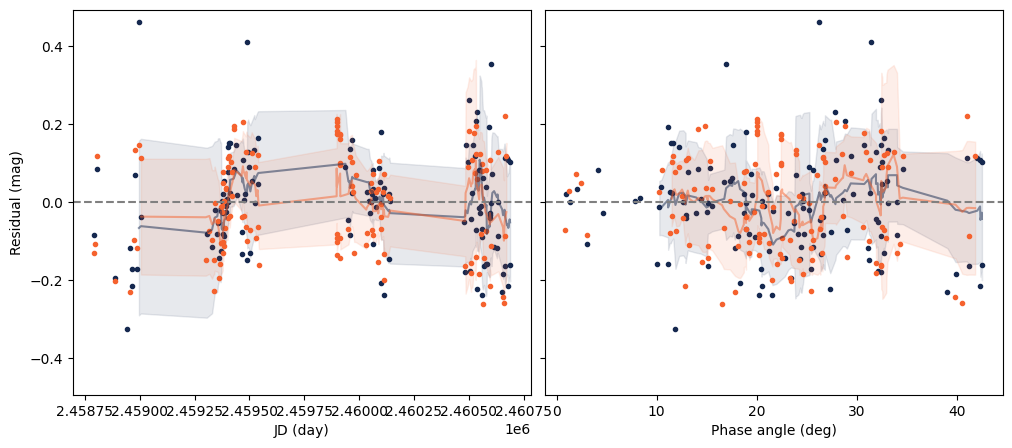

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for filtnum in pdf["i:fid"].unique():
    
    # By filter
    cond = pdf["i:fid"] == filtnum
    color = fink_colors[filtnum-1]
    
    # vs Time
    ax[0].scatter(pdf.loc[cond, "i:jd"], pdf.loc[cond, "res_sHG1G2"], color=color, marker=".")
    sorted = pdf[cond].sort_values("i:jd")
    x = sorted["i:jd"]
    y = sorted["res_sHG1G2"].rolling(10).mean()
    sy = sorted["res_sHG1G2"].rolling(10).std()
    ax[0].fill_between(x, y-sy, y+sy, color=color, alpha=0.1)
    ax[0].plot(x, y, color=color, alpha=0.5)
    
    # vs Phase angle
    ax[1].scatter(pdf.loc[cond, "Phase"], pdf.loc[cond, "res_sHG1G2"], color=color, marker=".")
    sorted = pdf[cond].sort_values("Phase")
    x = sorted["Phase"]
    y = sorted["res_sHG1G2"].rolling(10).mean()
    sy = sorted["res_sHG1G2"].rolling(10).std()
    ax[1].fill_between(x, y-sy, y+sy, color=color, alpha=0.1)
    ax[1].plot(x, y, color=color, alpha=0.5)
    
ax[0].axhline(0, ls="--", color="grey")
ax[1].axhline(0, ls="--", color="grey")

max_res = 0.4
max_res = 3.5* np.std( pdf['res_sHG1G2'])
ax[0].set_ylim(-max_res, max_res)
ax[0].set_xlabel("JD (day)")
ax[1].set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Residual (mag)")

# Fit ssHG1G2

## Synodic to sidereal

In [19]:
jd = pdf["i:jd"].tolist()
jd2 = (pdf["i:jd"].values +  period / 24.0).tolist()

eph = ssptools.ephemcc(name, jd, tcoor=2, observer="500")
eph2 = ssptools.ephemcc(name, jd2, tcoor=2, observer="500")

In [20]:
pdf['jd_ltc'] = compute_light_travel_correction( pdf["i:jd"], eph['Dobs'] )

In [21]:
for i in range(len(jd)):
    eph.loc[i, "angle"] = angle_between_vectors(
        eph.loc[i, ["px", "py", "pz"]].values, eph2.loc[i, ["px", "py", "pz"]].values
    )

In [22]:
# Sidereal Rotation in days
sidereal_period = synodic_to_sidereal(period / 24.0, 000)
print(sidereal_period * 24)

27.442386499364883


27.442386499364883 27.465854658667016 27.41891834006275


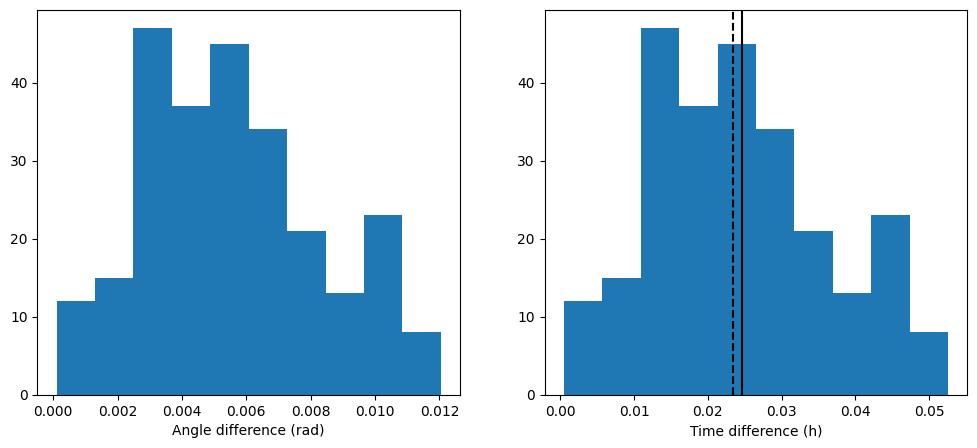

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(eph["angle"])

dephase = (eph["angle"] / (2 * np.pi)) * period
ax[1].hist(dephase)

ax[1].axvline( np.mean( dephase), color='black' )
ax[1].axvline( np.median( dephase), color='black', ls='dashed' )
# ax[1].axvline( np.mean( dephase), ls='dotted' )

ax[0].set_xlabel("Angle difference (rad)")
ax[1].set_xlabel("Time difference (h)")

print( period, period + np.median( dephase ), period - np.median( dephase ) )

In [53]:
(period - np.median( dephase )), 27.47

(27.41891834006275, 27.47)

In [54]:
# Test for 6605 to force initial value close to sidereal DAMIT
# sidereal_period = 118.69/24.
# print(sidereal_period*24)


# sidereal_period = 11.6027/24  # 5209
# sidereal_period = 12.2527/24 # 4209
sidereal_period = (period - np.median( dephase ))/24
sidereal_period = 27.47/24.

# Initial guess - V1
ra0 = np.radians(fit_shg1g2["alpha0"])
de0 = np.radians(fit_shg1g2["delta0"])
p0 = [
    fit_shg1g2["H_1"],
    fit_shg1g2["G1_1"],
    fit_shg1g2["G2_1"],
    ra0,
    de0,
    sidereal_period,
    fit_shg1g2['a_b'],
    fit_shg1g2['a_c'],
    0.0,
]

# Constrained Fit
fit_sshg1g2 = estimate_sso_params(
    pdf["i:magpsf_red"],
    pdf["i:sigmapsf"],
    np.radians(pdf["Phase"]),
    pdf["i:fid"],
    ra=np.radians(pdf["i:ra"]),
    dec=np.radians(pdf["i:dec"]),
    jd=pdf["jd_ltc"],
    model="SSHG1G2",
    p0=p0,
)

# Initial guess - V2: flipped spin
ra0 = (np.pi + np.radians(fit_shg1g2["alpha0"])) % (2 * np.pi)
de0 = -np.radians(fit_shg1g2["delta0"])
p0 = [
    fit_shg1g2["H_1"],
    fit_shg1g2["G1_1"],
    fit_shg1g2["G2_1"],
    ra0,
    de0,
    sidereal_period,
    fit_shg1g2['a_b'],
    fit_shg1g2['a_c'],
    0.0,
]

# Constrained Fit
fit_sshg1g2_alt = estimate_sso_params(
    pdf["i:magpsf_red"],
    pdf["i:sigmapsf"],
    np.radians(pdf["Phase"]),
    pdf["i:fid"],
    ra=np.radians(pdf["i:ra"]),
    dec=np.radians(pdf["i:dec"]),
    jd=pdf["jd_ltc"],
    model="SSHG1G2",
    p0=p0,
)

In [52]:
print("       sHG1G2  ssHG1G2  ss(alt)")
print(
    f"RMS  : {fit_shg1g2['rms']:6.3f}  {fit_sshg1g2['rms']:6.3f}  {fit_sshg1g2_alt['rms']:6.3f}"
)
print(
    f"chi2 : {fit_shg1g2['chi2red']:6.3f}  {fit_sshg1g2['chi2red']:6.3f}  {fit_sshg1g2_alt['chi2red']:6.3f}"
)
print()
print(
    f"H_1  : {fit_shg1g2['H_1']:6.2f}  {fit_sshg1g2['H_1']:6.2f}  {fit_sshg1g2_alt['H_1']:6.2f}"
)
print(
    f"H_2  : {fit_shg1g2['H_2']:6.2f}  {fit_sshg1g2['H_2']:6.2f}  {fit_sshg1g2_alt['H_2']:6.2f}"
)
print(
    f"G1_1 : {fit_shg1g2['G1_1']:6.2f}  {fit_sshg1g2['G1_1']:6.2f}  {fit_sshg1g2_alt['G1_1']:6.2f}"
)
print(
    f"G1_2 : {fit_shg1g2['G1_2']:6.2f}  {fit_sshg1g2['G1_2']:6.2f}  {fit_sshg1g2_alt['G1_2']:6.2f}"
)
print(
    f"G2_1 : {fit_shg1g2['G2_1']:6.2f}  {fit_sshg1g2['G2_1']:6.2f}  {fit_sshg1g2_alt['G2_1']:6.2f}"
)
print(
    f"G2_2 : {fit_shg1g2['G2_2']:6.2f}  {fit_sshg1g2['G2_2']:6.2f}  {fit_sshg1g2_alt['G2_2']:6.2f}"
)

print()
print(
    f"RA0  : {fit_shg1g2['alpha0']:6.1f}  {fit_sshg1g2['alpha0']:6.1f}  {fit_sshg1g2_alt['alpha0']:6.1f}"
)
print(
    f"DEC0 : {fit_shg1g2['delta0']:6.1f}  {fit_sshg1g2['delta0']:6.1f}  {fit_sshg1g2_alt['delta0']:6.1f}"
)
print(
    f"P(h) : {period:6.3f}  {fit_sshg1g2['period']*24:6.3f}  {fit_sshg1g2_alt['period']*24:6.3f}"
)
print(f"a/b  :         {fit_sshg1g2['a_b']:6.2f}  {fit_sshg1g2_alt['a_b']:6.2f}")
print(f"a/c  :         {fit_sshg1g2['a_c']:6.2f}  {fit_sshg1g2_alt['a_c']:6.2f}")


root = f"{num}_{name}".replace(" ", "_")
with open(os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}.csv"), "w") as f:
    f.write(f"par,sHG1G2,ssHG1G2,ssHG1G2_alt\n")
    f.write(f"RMS,{fit_shg1g2['rms']},{fit_sshg1g2['rms']},{fit_sshg1g2_alt['rms']}\n")
    f.write(
        f"chi2,{fit_shg1g2['chi2red']},{fit_sshg1g2['chi2red']},{fit_sshg1g2_alt['chi2red']}\n"
    )

    f.write(f"H_1,{fit_shg1g2['H_1']},{fit_sshg1g2['H_1']},{fit_sshg1g2_alt['H_1']}\n")
    f.write(
        f"err_H_1,{fit_shg1g2['err_H_1']},{fit_sshg1g2['err_H_1']},{fit_sshg1g2_alt['err_H_1']}\n"
    )
    f.write(
        f"G1_1,{fit_shg1g2['G1_1']},{fit_sshg1g2['G1_1']},{fit_sshg1g2_alt['G1_1']}\n"
    )
    f.write(
        f"G2_1,{fit_shg1g2['G2_1']},{fit_sshg1g2['G2_1']},{fit_sshg1g2_alt['G2_1']}\n"
    )
    f.write(
        f"err_G1_1,{fit_shg1g2['err_G1_1']},{fit_sshg1g2['err_G1_1']},{fit_sshg1g2_alt['err_G1_1']}\n"
    )
    f.write(
        f"err_G2_1,{fit_shg1g2['err_G2_1']},{fit_sshg1g2['err_G2_1']},{fit_sshg1g2_alt['err_G2_1']}\n"
    )

    f.write(f"H_2,{fit_shg1g2['H_2']},{fit_sshg1g2['H_2']},{fit_sshg1g2_alt['H_2']}\n")
    f.write(
        f"err_H_2,{fit_shg1g2['err_H_2']},{fit_sshg1g2['err_H_2']},{fit_sshg1g2_alt['err_H_2']}\n"
    )
    f.write(
        f"G1_2,{fit_shg1g2['G1_2']},{fit_sshg1g2['G1_2']},{fit_sshg1g2_alt['G1_2']}\n"
    )
    f.write(
        f"G2_2,{fit_shg1g2['G2_2']},{fit_sshg1g2['G2_2']},{fit_sshg1g2_alt['G2_2']}\n"
    )
    f.write(
        f"err_G1_2,{fit_shg1g2['err_G1_2']},{fit_sshg1g2['err_G1_2']},{fit_sshg1g2_alt['err_G1_2']}\n"
    )
    f.write(
        f"err_G2_2,{fit_shg1g2['err_G2_2']},{fit_sshg1g2['err_G2_2']},{fit_sshg1g2_alt['err_G2_2']}\n"
    )

    f.write(
        f"alpha0,{fit_shg1g2['alpha0']},{fit_sshg1g2['alpha0']},{fit_sshg1g2_alt['alpha0']}\n"
    )
    f.write(
        f"delta0,{fit_shg1g2['delta0']},{fit_sshg1g2['delta0']},{fit_sshg1g2_alt['delta0']}\n"
    )
    f.write(
        f"err_alpha0,{fit_shg1g2['err_alpha0']},{fit_sshg1g2['err_alpha0']},{fit_sshg1g2_alt['err_alpha0']}\n"
    )
    f.write(
        f"err_delta0,{fit_shg1g2['err_delta0']},{fit_sshg1g2['err_delta0']},{fit_sshg1g2_alt['err_delta0']}\n"
    )

    f.write(f"P,{period},{fit_sshg1g2['period']*24},{fit_sshg1g2_alt['period']*24}\n")
    f.write(f"a_b,,{fit_sshg1g2['a_b']},{fit_sshg1g2_alt['a_b']}\n")
    f.write(f"a_c,,{fit_sshg1g2['a_c']},{fit_sshg1g2_alt['a_c']}\n")
    f.write(
        f"err_P, ,{fit_sshg1g2['err_period']*24},{fit_sshg1g2_alt['err_period']*24}\n"
    )
    f.write(f"err_a_b,,{fit_sshg1g2['err_a_b']},{fit_sshg1g2_alt['err_a_b']}\n")
    f.write(f"err_a_c,,{fit_sshg1g2['err_a_c']},{fit_sshg1g2_alt['err_a_c']}\n")

       sHG1G2  ssHG1G2  ss(alt)
RMS  :  0.141   0.099   0.085
chi2 : 21.387   9.875   7.445

H_1  :  13.25   13.55   13.56
H_2  :  12.56   12.80   12.89
G1_1 :   0.50    0.58    0.51
G1_2 :   0.36    0.34    0.49
G2_1 :   0.22    0.23    0.25
G2_2 :   0.31    0.34    0.28

RA0  :   86.2    78.3   268.4
DEC0 :  -18.7   -28.6   -31.4
P(h) : 27.442  27.473  27.471
a/b  :           1.46    1.56
a/c  :           1.78    1.71


In [41]:
# --------------------------------------------------------------------------------
# Compute residuals
for filtnum in pdf["i:fid"].unique():

    # Input variables
    cond = pdf["i:fid"] == filtnum

    coord = SkyCoord(
        ra=pdf.loc[cond, "i:ra"], dec=pdf.loc[cond, "i:dec"], unit=("deg", "deg")
    )
    data_ra = coord.ra.rad
    data_dec = coord.dec.rad
    data_jd = pdf.loc[cond, "jd_ltc"]
    data_phase = np.radians(pdf.loc[cond, "Phase"])
    data_mag = pdf.loc[cond, "i:magpsf_red"]

    pha = [data_phase.values, data_ra, data_dec, data_jd.values]

    # ssHG1G2
    model = func_sshg1g2(
        pha,
        fit_sshg1g2[f"H_{filtnum}"],
        fit_sshg1g2[f"G1_{filtnum}"],
        fit_sshg1g2[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2["alpha0"]),
        np.radians(fit_sshg1g2["delta0"]),
        fit_sshg1g2["period"],
        fit_sshg1g2["a_b"],
        fit_sshg1g2["a_c"],
        fit_sshg1g2["phi0"],
    )

    model_alt = func_sshg1g2(
        pha,
        fit_sshg1g2_alt[f"H_{filtnum}"],
        fit_sshg1g2_alt[f"G1_{filtnum}"],
        fit_sshg1g2_alt[f"G2_{filtnum}"],
        np.radians(fit_sshg1g2_alt["alpha0"]),
        np.radians(fit_sshg1g2_alt["delta0"]),
        fit_sshg1g2_alt["period"],
        fit_sshg1g2_alt["a_b"],
        fit_sshg1g2_alt["a_c"],
        fit_sshg1g2_alt["phi0"],
    )

    pdf.loc[cond, f"res_ssHG1G2"] = data_mag - model
    pdf.loc[cond, f"res_ssHG1G2_alt"] = data_mag - model_alt

/tmp/ipykernel_52940/1987799648.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


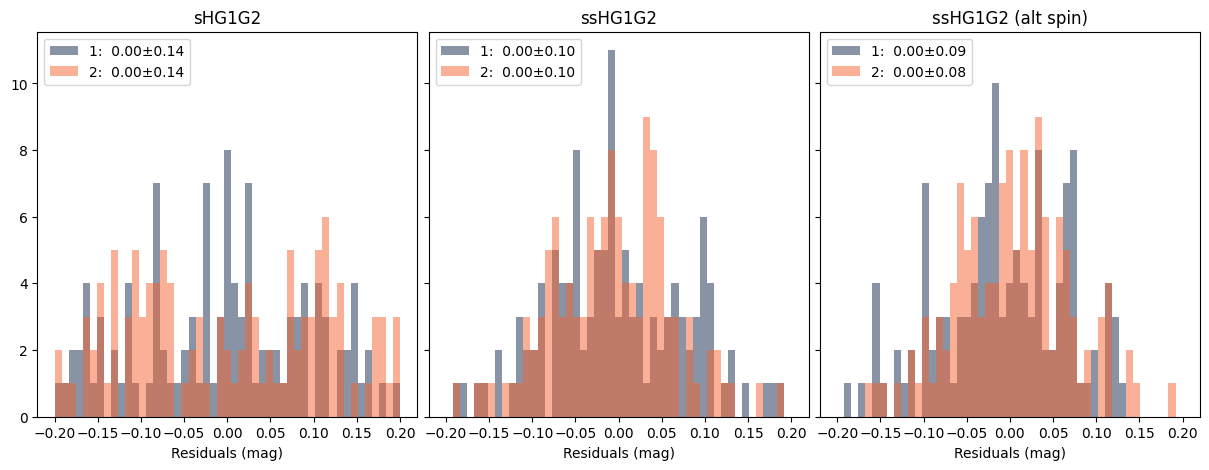

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

max_res = 0.2
bins = np.linspace(-max_res, max_res, 50)
for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    mu, std = np.mean(pdf.loc[cond, "residuals"]), np.std(pdf.loc[cond, "residuals"])
    ax[0].hist(
        pdf.loc[cond, "residuals"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )

    # V1
    mu, std = np.mean(pdf.loc[cond, "res_ssHG1G2"]), np.std(
        pdf.loc[cond, "res_ssHG1G2"]
    )
    ax[1].hist(
        pdf.loc[cond, "res_ssHG1G2"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )

    # V2 - alt
    mu, std = np.mean(pdf.loc[cond, "res_ssHG1G2_alt"]), np.std(
        pdf.loc[cond, "res_ssHG1G2_alt"]
    )
    ax[2].hist(
        pdf.loc[cond, "res_ssHG1G2_alt"],
        bins=bins,
        alpha=0.5,
        color=fink_colors[i],
        label=f"{filtnum}: {mu:5.2f}±{std:.2f}",
    )


ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")
for a in ax:
    a.set_xlabel("Residuals (mag)")
    a.legend(loc="upper left")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_hist.png"),
    dpi=180,
    facecolor="white",
)

/tmp/ipykernel_52940/3275797286.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


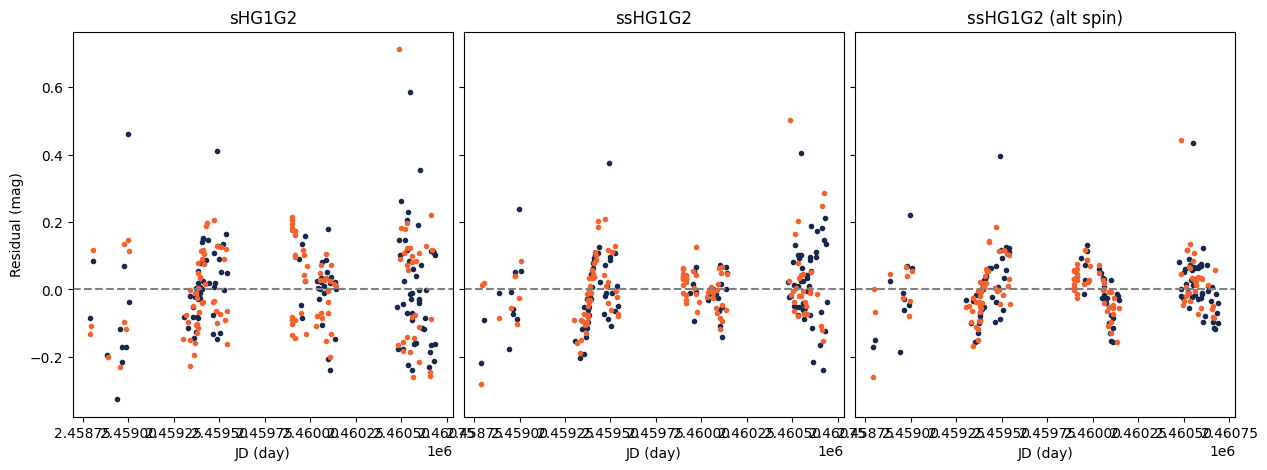

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    ax[0].scatter(
        pdf["i:jd"][cond],
        pdf["residuals"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[1].scatter(
        pdf["i:jd"][cond],
        pdf["res_ssHG1G2"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[2].scatter(
        pdf["i:jd"][cond],
        pdf["res_ssHG1G2_alt"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )

for a in ax:
    a.axhline(0, ls="--", color="grey")
    a.set_xlabel("JD (day)")
ax[0].set_ylabel("Residual (mag)")

ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_jd.png"),
    dpi=180,
    facecolor="white",
)

/tmp/ipykernel_52940/790428671.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


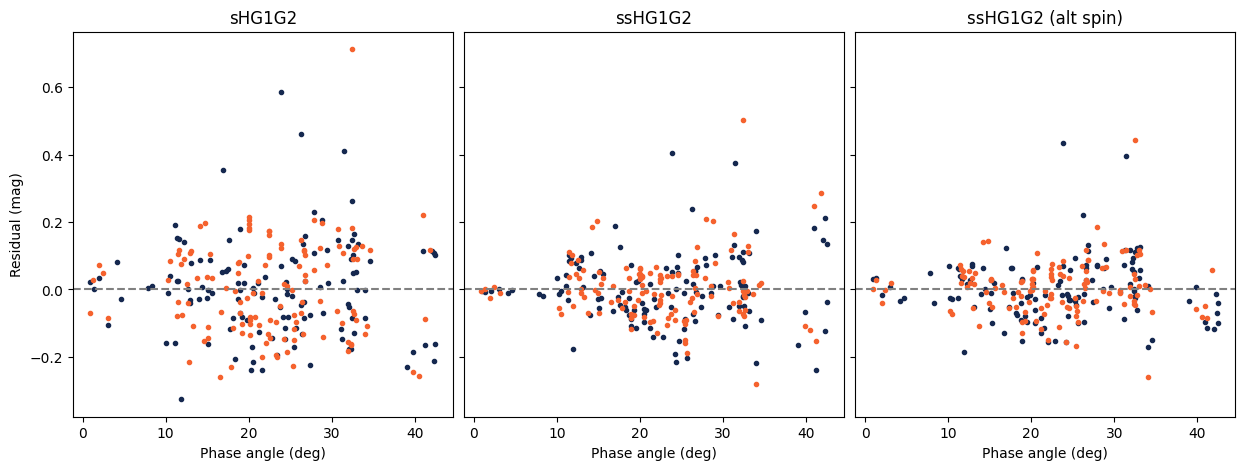

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, gridspec_kw={"wspace": 0.03})

for i, filtnum in enumerate(pdf["i:fid"].unique()):
    cond = pdf["i:fid"] == filtnum
    ax[0].scatter(
        pdf["Phase"][cond],
        pdf["residuals"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[1].scatter(
        pdf["Phase"][cond],
        pdf["res_ssHG1G2"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )
    ax[2].scatter(
        pdf["Phase"][cond],
        pdf["res_ssHG1G2_alt"][cond],
        marker=".",
        color=fink_colors[i],
        label=f"{filtnum}",
    )

for a in ax:
    a.axhline(0, ls="--", color="grey")
    a.set_xlabel("Phase angle (deg)")
ax[0].set_ylabel("Residual (mag)")

ax[0].set_title("sHG1G2")
ax[1].set_title("ssHG1G2")
ax[2].set_title("ssHG1G2 (alt spin)")

fig.tight_layout()
fig.savefig(
    os.path.join("..", "..", "gfx", "ssHG1G2", f"{root}_res_phase.png"),
    dpi=180,
    facecolor="white",
)